<a href="https://colab.research.google.com/github/yumx100/2026-AUC_Cognitive-Psychology/blob/main/week5_visual_masking.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Visual Masking

### Background
This experiment was based on an experiment by Mulckhuyse, Talsma, & Theeuwes (2007). The experiment explores the influence of an ‘invisible’ dot on attention. Figure 1 shows a schematic overview of a single trial. On each trial, an ‘invisible’ dot was presented very briefly (±17 ms) on the right or the left of the display. This was immediately followed by a visual mask consisting of three dots. In other words, one of the three dots was presented 17 ms earlier than the others. The mask is there to mask (i.e. hide) the presence of the invisible dot. On 80% of all trials, there was also a small black dot on the left or right side of the mask.

While the invisible dot was not consciously seen, it did capture the participants’ attention. Note how this requires a strong distinction between attention and awareness (Lamme, 2003). On some trials the invisible dot would pull attention towards the small black dot (valid condition), and on other trials it pulled attention away from the small black dot (invalid condition). On 20% of trials there was no small black dot (catch trials).


![Visual Masking Experiment](https://docs.google.com/uc?export=download&id=1WfRvFiTylqo_ESKIoj7c4nwN1cvAu7RK)

The experiment comprised two tasks:

1. Task 1 was a speeded response task, where participants pressed spaced when they saw the small black dot. When there was no small black dot, no response was to be given.
2. Task 2 was an accuracy task, where participants indicated on which side they thought the invisible grey dot appeared.

The experiment you did is an adapted online version of Mulckhuyse, Talsma, & Theeuwes (2007).

**References**:
- Mulckhuyse, M., Talsma, D., & Theeuwes, J. (2007). Grabbing attention without knowing: Automatic capture of attention by subliminal spatial cues. Visual Cognition, 15(7), 779-788.  
- Optional: Lamme, V. A. (2003). Why visual attention and awareness are different. Trends in cognitive sciences, 7(1), 12-18.



In [1]:
# This cell load the data. You don't need to change it or understand it. Just run the cell.
import pandas as pd

file_id = '1fzgXa2Dp-H-EMo5jwKD0XLHO0HXQSdSW'
url = f'https://docs.google.com/uc?export=download&id={file_id}'
df = pd.read_csv(url)

In [ ]:
df

,username,duration,RTvalid,RTinvalid,percent_too_slow,percent_false_alarms,percent_outliers,percent_correct,answer
0,A01,6.81,387.34375,390.71875,0.0000,12.50,3.1250,55.0,No
1,A02,16.92,469.50000,488.87500,1.5625,6.25,4.6875,80.0,No
2,A03,17.03,364.84375,346.43750,0.0000,6.25,6.2500,45.0,No
3,A04,17.42,375.65625,393.12500,0.0000,12.50,7.8125,55.0,No
4,A05,17.14,388.03125,397.21875,0.0000,0.00,6.2500,60.0,No
5,A06,17.54,421.09375,453.21875,0.0000,12.50,3.1250,50.0,No
6,A07,16.69,345.84375,344.50000,0.0000,0.00,4.6875,70.0,No
7,A10,17.17,426.09375,464.15625,0.0000,0.00,7.8125,75.0,No
8,A11,5.40,306.50000,327.53125,0.0000,0.00,1.5625,35.0,No
9,A12,16.64,374.06250,411.59375,0.0000,6.25,3.1250,70.0,No


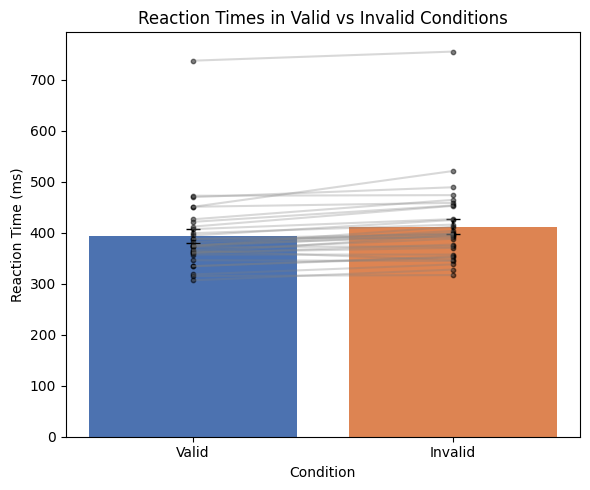

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Extract data
valid = df['RTvalid']
invalid = df['RTinvalid']

# Means
mean_valid = np.mean(valid)
mean_invalid = np.mean(invalid)

# Standard Error (SEM)
sem_valid = np.std(valid, ddof=1) / np.sqrt(len(valid))
sem_invalid = np.std(invalid, ddof=1) / np.sqrt(len(invalid))

# Plot
plt.figure(figsize=(6,5))

conditions = ['Valid', 'Invalid']
means = [mean_valid, mean_invalid]
errors = [sem_valid, sem_invalid]

plt.bar(conditions, means, yerr=errors, capsize=5,
        color=['#4C72B0', '#DD8452'])

for i in range(len(df)):
    plt.plot(['Valid', 'Invalid'],
             [valid.iloc[i], invalid.iloc[i]],
             color='gray', alpha=0.3)

    plt.scatter(['Valid', 'Invalid'],
                [valid.iloc[i], invalid.iloc[i]],
                color='black', s=10, alpha=0.5)

# Labels
plt.ylabel('Reaction Time (ms)')
plt.xlabel('Condition')
plt.title('Reaction Times in Valid vs Invalid Conditions')

# Optional: cleaner look
plt.tight_layout()

# Save figure (important for report)
plt.savefig('figure1_RT.png', dpi=300)

plt.show()

**Note**: The 'percent_correct' column is based on Task 2 only. Columns 'RTvalid', 'RTinvalid', and 'percent_too_slow' are based on Task 1 only.

<div style="background-color: #d1ecf1; border-left: 5px solid #0dcaf0; padding: 10px; margin: 10px 0;">
<strong>Insight</strong>: Would you expect faster response times (RTs) for the valid or the invalid condition?
</div>

### Task 1 (respond quickly to the small black target dot)
First, we would like to test if there is a significant difference in RTs between the valid and invalid condition in Task 1. To do this, we can use a paired-samples t-test. We could do this in JASP like we did in Week 1, but we will do it in Python for now so that we can stick with one tool. You willl do further statistical analyses in JASP at the end of the notebook.

In [ ]:
from scipy.stats import ttest_rel

# Perform a paired-samples t-test
t_statistic, p_value = ttest_rel(df['RTvalid'], df['RTinvalid'])
degrees_of_freedom = len(df) - 1

print(f't-statistic: {t_statistic:.4f}')
print(f'degrees of freedom: {degrees_of_freedom}')
print(f'p-value: {p_value:.4f}')

t-statistic: -6.2479
degrees of freedom: 30
p-value: 0.0000


<div style="background-color: #d1ecf1; border-left: 5px solid #0dcaf0; padding: 10px; margin: 10px 0;">
<strong>Insight</strong>: Did the "invisible" dot capture attention?
</div>

<div style="background-color: #d1ecf1; border-left: 5px solid #0dcaf0; padding: 10px; margin: 10px 0;">
<strong>Insight</strong>: The column 'percent_false_alarms' indicates the % of trials where participants pressed space when they shouldn’t have (i.e., when there was no small black dot). What is the point of this column? Do you think we should remove any participants from the analysis?
</div>

##### Awareness question
After Task 1, participants received an explanation that one of the grey dots appeared earlier. Then, they were asked whether they noticed this. The answer to that question is in the column ‘answer’.

Do the same t-test that you did earlier, but only include the participants that answered ‘No’ by completing the code below.

In [ ]:
filtered_df = df[df['answer'] == 'No'].copy()

# Perform a paired-samples t-test
t_statistic, p_value = ttest_rel(filtered_df['RTvalid'], filtered_df['RTinvalid'])
degrees_of_freedom = len(filtered_df) - 1

print(f't-statistic: {t_statistic:.4f}')
print(f'degrees of freedom: {degrees_of_freedom}')
print(f'p-value: {p_value:.4f}')

t-statistic: -5.3127
degrees of freedom: 26
p-value: 0.0000


<div style="background-color: #d1ecf1; border-left: 5px solid #0dcaf0; padding: 10px; margin: 10px 0;">
<strong>Insight</strong>: Is the outcome of this t-test different? If so, why do you think that is the case?
</div>

### Task 2 (indicate the location of the invisible grey dot)

<div style="background-color: #d1ecf1; border-left: 5px solid #0dcaf0; padding: 10px; margin: 10px 0;">
<strong>Insight</strong>: If the "invisible" dot was really invisible, what would you expect as the accuracy in Task 2?
</div>

To see if the dot was really invisible, we can test whether the accuracy in Task 2 is significantly different from chance level (50%). To do this, we can use a one-sample t-test. You can do this in JASP, but you can also do it in Python by completing the code below.

In [ ]:
from scipy.stats import ttest_1samp

# Perform a one-sample t-test against chance level (50%)
t_statistic, p_value = ttest_1samp(filtered_df['percent_correct'], 0.5)
degrees_of_freedom = len(filtered_df) - 1

print(f't-statistic: {t_statistic:.4f}')
print(f'degrees of freedom: {degrees_of_freedom}')
print(f'p-value: {p_value:.4f}')

t-statistic: 19.8134
degrees of freedom: 26
p-value: 0.0000


<div style="background-color: #d1ecf1; border-left: 5px solid #0dcaf0; padding: 10px; margin: 10px 0;">
<strong>Insight</strong>: Was the invisible dot truly invisible?
</div>

The invisible dot was meant to be shown for only 17 ms, but unfortunately not all computers can handle the speed of this experiment. The column ‘duration’ shows the average time (in ms) that the invisible dot was actually shown for each participant. Do you see any issues?

Remove all rows for participants with an average duration higher than 17 ms. Then, repeat the one-sample t-test to see if the dot was truly invisible for the remaining participants.

In [ ]:
filtered_df = filtered_df[filtered_df['duration'] < 18]

# Perform a one-sample t-test against chance level (50%)
t_statistic, p_value = ttest_1samp(filtered_df['percent_correct'], 0.5)
degrees_of_freedom = len(filtered_df) - 1
print(f't-statistic: {t_statistic:.4f}')
print(f'degrees of freedom: {degrees_of_freedom}')
print(f'p-value: {p_value:.4f}')

t-statistic: 19.6222
degrees of freedom: 24
p-value: 0.0000


Was the dot invisible? To answer the previous question, you will need Bayesian statistics. Open the file visual-masking_JASP.csv in the JASP. Perform a Bayesian one-sample t-test on the variable accuracy, with 50 as the test value. By default, JASP will use a Cauchy distribution with a scale of 0.707 as prior, which is good for now.

In [ ]:
from google.colab import files

# Download the file to your computer
filtered_df.to_csv('visual-masking_JASP.csv', index=False)
files.download('visual-masking_JASP.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<div style="background-color: #d1ecf1; border-left: 5px solid #0dcaf0; padding: 10px; margin: 10px 0;">
<strong>Insight</strong>: Can you think of any other analyses that might have been interesting?
</div>

#### Experimental design
1. What do you think about the order of Task 1 and 2? What would happen if we started with Task 2?
2. Task 1 had 80 trials, while Task 2 had 20. Do you think this makes sense?
3. Are there any aspects of the experiment that could be improved?
